In [1]:
##modules
#%matplotlib widget
%matplotlib inline
#
#%matplotlib qt
import mne
import numpy as np
import matplotlib
# Establecer un backend interactivo, como 'Qt5Agg', 'GTK3Agg', etc.
# Esto depende de los backends disponibles en tu sistema.

import matplotlib.pyplot as plt

#matplotlib.use('TkAgg')  # Asegúrate de que este backend está instalado.

import pandas as pd 
import os
import sys

from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs

from os.path import join as pathjoin
from time import time

from pathlib import Path

from autoreject import AutoReject

# aplicar la acf EN epochs

from statsmodels.tsa.stattools import acf


from scipy.stats import permutation_test

sys.path.append(r"G:\apuntes_mne\code_MOUS\scripts_functions_created")

# Ahora importa la función
from print5 import print5

In [2]:

 
try:
    # Si se ejecuta como SCRIPT .py: usar __file__
    sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
except NameError:
    # Si se ejecuta como NOTEBOOK Jupyter: usar path relativo
    sys.path.append("..")  # sube un nivel desde la carpeta actual del notebook


# --- Configuración dinámica de rutas ---
from get_paths_MOUS import get_paths_MOUS

# Parámetros editables
disco = "g"
modality = "visual"
layer_script = "block"
subj = "sub-V1001"
#subj = sys.argv[1] ## name of participant list


# Generar variables automáticamente
path_dict = get_paths_MOUS(disco=disco, modality=modality, layer_script=layer_script, subj=subj)
globals().update(path_dict)

# Mostrar todos los paths generados
print("\n📁 Rutas generadas:")
for k, v in path_dict.items():
    print(f"{k:<20} → {v}")




📁 Rutas generadas:
datadir              → g:\MOUS_204\MOUS_visual
general_datadir      → g:\MOUS_204
output_preproc       → g:\MOUS_204\MOUS_visual\output_preproc
mri_dir              → g:\MOUS_204\sub-V1001\anat
meg_dir              → g:\MOUS_204\sub-V1001\meg
preproc_path         → g:\MOUS_204\MOUS_visual\output_preproc\preproc_block
channels_structure_path → g:\MOUS_204\channels_structure
epochs_path          → g:\MOUS_204\MOUS_visual\output_preproc\preproc_block\epochs_block
ICA_path             → g:\MOUS_204\MOUS_visual\output_preproc\preproc_block\ICA_block
epochs_clean_path    → g:\MOUS_204\MOUS_visual\output_preproc\preproc_block\epochs_clean_block
evoked_path          → g:\MOUS_204\MOUS_visual\output_preproc\preproc_block\evoked_block
source_path          → g:\MOUS_204\MOUS_visual\output_source\source_block
raw_hsp_path         → g:\MOUS_204\MOUS_visual\output_source\source_block\raw_hsp
fwd_path             → g:\MOUS_204\MOUS_visual\output_source\source_block\fwd
inverse_pat

In [3]:
# # def print5(*args):
# #     print(*(f"{x:.5f}" if isinstance(x, float) else x for x in args))

# # channels = pd.read_csv(channels_structure_path / f"channels_mag_{modality}.csv")
# # channels_mag=channels[channels[f"canal_efectivo_{modality}"].notna()][f"canal_efectivo_{modality}"]

# # channels_mag=channels_mag.tolist()
# # print5(channels_mag)
# # indice_channels_efectivos = channels[channels[f"canal_efectivo_{modality}"].notna()]["indice"]
# # indice_channels_efectivos=indice_channels_efectivos.tolist()
# # # del channels

# # # del channels

In [4]:
# ##channels significant adjusted in each condition
# numbers_channels_woorden= dict_woorden_block["significant_channels_adjusted_woorden"]
# numbers_channels_zinnen= dict_zinnen_block["significant_channels_adjusted_zinnen"]
# print("numbers_channels_woorden", numbers_channels_woorden, "len=",len(numbers_channels_woorden))

# print("numbers_channels_zinnen", numbers_channels_zinnen, "len=", len(numbers_channels_zinnen))


In [5]:
dict_isc= pd.read_pickle(ISC_path /f"ISC_results_{layer_script}.pkl")
dict_woorden_block=dict_isc['dict_isc_WOORDEN']
dict_zinnen_block = dict_isc['dict_isc_ZINNEN']

##channels significant adjusted in each condition
numbers_channels_woorden= dict_woorden_block["significant_channels_adjusted"]
numbers_channels_zinnen= dict_zinnen_block["significant_channels_adjusted"]
print("numbers_channels_woorden", numbers_channels_woorden, "numbers_channels_zinnen", numbers_channels_zinnen)
print("len(numbers_channels_woorden)=",len(numbers_channels_woorden),  "len(numbers_channels_zinnen)=",len(numbers_channels_zinnen))


# names_channels_woorden=[channels_mag[i] for i in numbers_channels_woorden]
# names_channels_zinnen=[channels_mag[i] for i in numbers_channels_zinnen]

# print("names_channels_woorden", names_channels_woorden)
# print("names_channels_zinnen", names_channels_zinnen)

#establecimiento de canales palabras, canales frases y canales mixtos
numbers_channels_only_woorden = list(
    set(numbers_channels_woorden) - set(numbers_channels_zinnen)
)

numbers_channels_only_zinnen = list(
    set(numbers_channels_zinnen) - set(numbers_channels_woorden)
)

number_channels_intersection = list(
    set(numbers_channels_woorden) & set(numbers_channels_zinnen)
)

print(f"len(significant_channels_only_woorden): {len(numbers_channels_only_woorden)},\
      len(significant_channels_only_zinnen): {len(numbers_channels_only_zinnen)},\
      len(significant_channels_intersection) {len(number_channels_intersection)}")

#create list of names of channels

# names_channels_only_woorden = [channels_mag[i] for i in numbers_channels_only_woorden]
# names_channels_only_zinnen = [channels_mag[i] for i in numbers_channels_only_zinnen]
# names_channels_intersection = [channels_mag[i] for i in number_channels_intersection]

numbers_channels_woorden [  0   1   2   3   4   5   7   8   9  10  11  12  13  14  17  18  19  21
  33  34  36  39  40  41  42  43  44  45  46  47  48  52  53  54  55  56
  57  58  60  61  62  63  64  65  66  68  69  70  72  73  75  77  78  79
  80  81  82  83  84  85  86  87  88  90  91  92  93  94  95  96  97  98
  99 100 101 103 104 105 107 108 109 110 111 112 113 114 115 116 117 118
 119 120 121 122 123 124 125 126 127 128 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 146 147 148 149 161 166 172 177 178 182 183
 184 187 188 197 198 199 200 201 202 204 207 209 210 211 212 213 214 215
 216 217 220 221 222 223 224 225 226 227 230 231 232 233 234 237 238 239
 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257
 258] numbers_channels_zinnen [  2   3   4   5   7   8   9  10  11  12  13  14  17  18  19  24  25  28
  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46
  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  66 

In [6]:
iscs_bootstrap_woorden=dict_woorden_block["iscs_bootstrap"]
iscs_bootstrap_zinnen=dict_zinnen_block["iscs_bootstrap"]

TRW= iscs_bootstrap_zinnen - iscs_bootstrap_woorden

## PLOTS for ISCS

In [ ]:
##plots for ISC

#read epochs to build evoked
# leer epochs del sujeto (único archivo)
epochs = mne.read_epochs(epochs_clean_path / f"{subj}_epochs_{layer_script}-epo.fif")

# seleccionar ensayos de condición "zinnen"
epochs_zinnen = epochs["fix_ZINNEN"]

# obtener evoked
evoked_zinnen = epochs_zinnen.copy().pick("mag", exclude="bads").average()

info = evoked_zinnen.info

# limpieza memoria (opcional)
del epochs, epochs_zinnen

Reading g:\MOUS_204\MOUS_visual\output_preproc\preproc_block\epochs_clean_block\sub-V1001_epochs_block-epo.fif ...
    Found the data of interest:
        t =       0.00 ...   60000.00 ms
        0 CTF compensation matrices available
Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated


ISCs are: iscs_bootstrap_woorden
ISCs are: iscs_bootstrap_zinnen


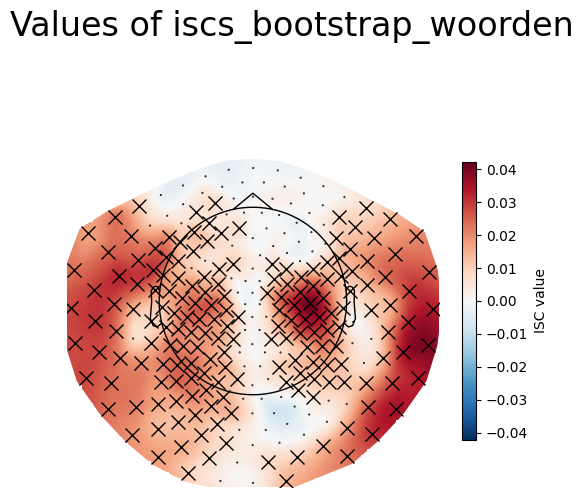

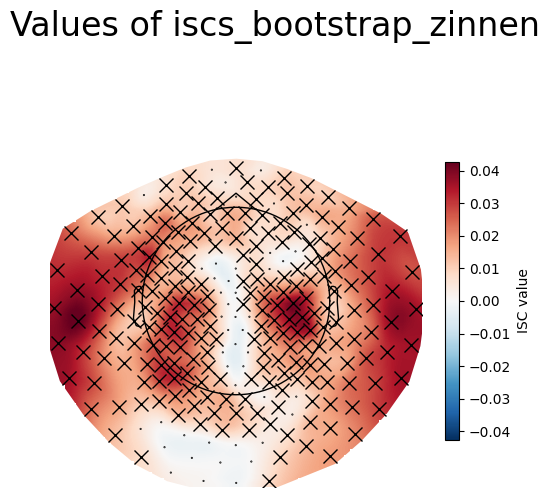

In [8]:



#Possible masks

mask_zinnen= np.zeros(iscs_bootstrap_woorden.shape, dtype=bool)
for electrode in numbers_channels_zinnen:
    mask_zinnen[electrode] = True 

mask_woorden= np.zeros(iscs_bootstrap_woorden.shape, dtype=bool)
for electrode in numbers_channels_woorden:
    mask_woorden[electrode] = True

mask_zinnen_only= np.zeros(iscs_bootstrap_woorden.shape, dtype=bool)
for electrode in numbers_channels_only_zinnen:
    mask_zinnen_only[electrode] = True 

mask_woorden_only= np.zeros(iscs_bootstrap_woorden.shape, dtype=bool)
for electrode in numbers_channels_only_woorden:
    mask_woorden_only[electrode] = True


mask_intersection= np.zeros(iscs_bootstrap_woorden.shape, dtype=bool)
for electrode in number_channels_intersection:
    mask_intersection[electrode] = True 


##in data i use the value of t_obs_zinnen
#pos takes the information from evoked.info object
#mask takes the mask_zinnen object
#in t stat i don´t change it becausse the p value will be calculated with permutations, so no problem when using a parametric test,
# even if the distribution is non parametric 
dict_masks= {"mask_zinnen":mask_zinnen,
            "mask_woorden":mask_woorden,
            "mask_intersection": mask_intersection,
            "mask_zinnen_only": mask_zinnen_only,
            "mask_woorden_only": mask_woorden_only,
            }

iscs_bootstrap={"iscs_bootstrap_woorden":iscs_bootstrap_woorden, "iscs_bootstrap_zinnen":iscs_bootstrap_zinnen}

for iscs_name, values in iscs_bootstrap.items():
    print(f"ISCs are: {iscs_name}")

    # Seleccionamos la máscara correcta
    if iscs_name == "iscs_bootstrap_zinnen":
        mask = mask_zinnen
    elif iscs_name == "iscs_bootstrap_woorden":
        mask = mask_woorden

    # Creamos figura y eje
    fig, ax = plt.subplots(figsize=(6, 6))

    # Dibujamos topomap sobre ese eje
    im, _ = mne.viz.plot_topomap(
        data=values,
        pos=info,
        mask=mask,
        axes=ax,
        cmap='RdBu_r',
        vlim=(-np.max(np.abs(values)), np.max(np.abs(values))),
        mask_params=dict(marker='x', markerfacecolor='green', markersize=10),
        contours=0,
        show=False  # lo mostramos al final
    )

    # Añadir título y colorbar
    fig.suptitle(f"Values of {iscs_name}", fontsize=24)
    cbar = fig.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label("ISC value")
    del mask
    # Save the figure with a specific filename
    # fig.savefig(ISC_path / f"{mask_name}_words.png", dpi=300, bbox_inches='tight')



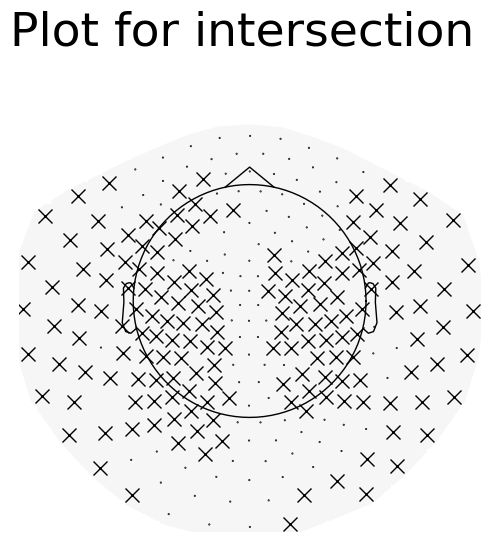

In [9]:

##plots of intersection

mask= mask_intersection
fig, ax = plt.subplots(figsize=(6, 6))  # Tamaño explícito

im, _ = mne.viz.plot_topomap(
    data=np.zeros(iscs_bootstrap_woorden.shape),        
    pos=info,
    mask=mask,
    axes=ax,  # usar el eje explícito
    cmap='RdBu_r',
    vlim=(-np.max(np.abs(values)), np.max(np.abs(values))),
    mask_params=dict(marker='x', markerfacecolor='green', markersize=10),
    contours=0,
    show=False
)


fig.suptitle("Plot for intersection", fontsize=34)

# cbar = fig.colorbar(im, ax=ax, shrink=0.6)
# cbar.set_label("Values")

plt.show()

del mask

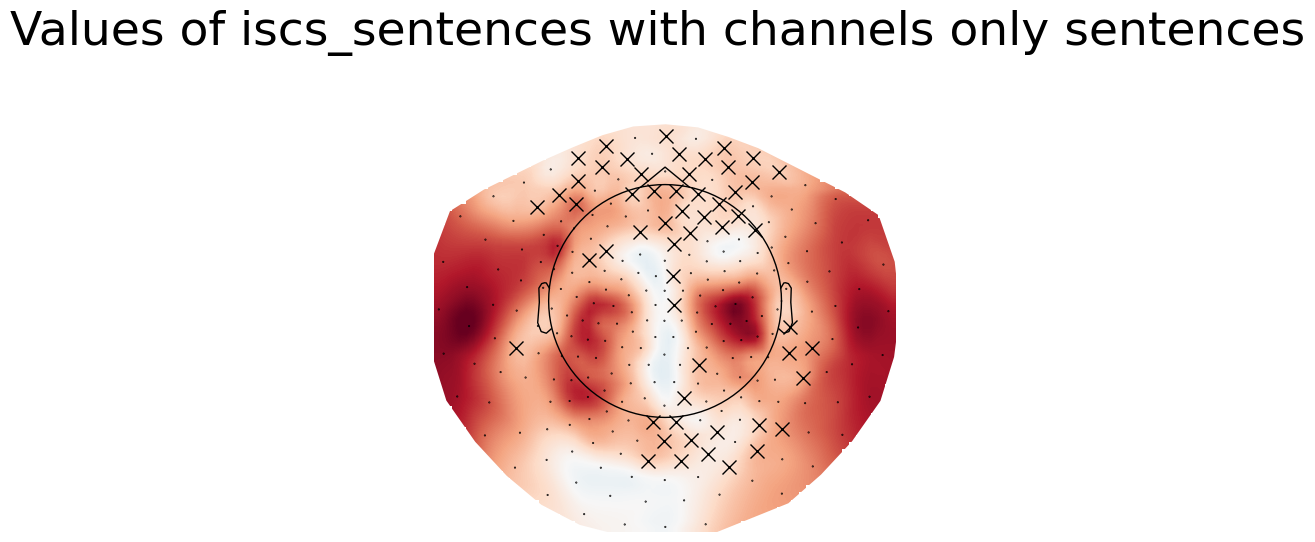

In [10]:
##plot for only zinnen
mask = mask_zinnen_only

# Crear figura y eje con tamaño definido
fig, ax = plt.subplots(figsize=(6, 6))

# Dibujar el topomap sobre ese eje
im, _ = mne.viz.plot_topomap(
    data=iscs_bootstrap_zinnen,        
    pos=info,
    mask=mask,
    axes=ax,  # eje explícito
    cmap='RdBu_r',
    vlim=(-np.max(np.abs(values)), np.max(np.abs(values))),
    mask_params=dict(marker='x', markerfacecolor='green', markersize=10),
    contours=0,
    show=False  # mostrar después
)

# Título
fig.suptitle("Values of iscs_sentences with channels only sentences", fontsize=34)

# Mostrar figura
plt.show()

# Eliminar máscara para evitar conflictos posteriores
del mask

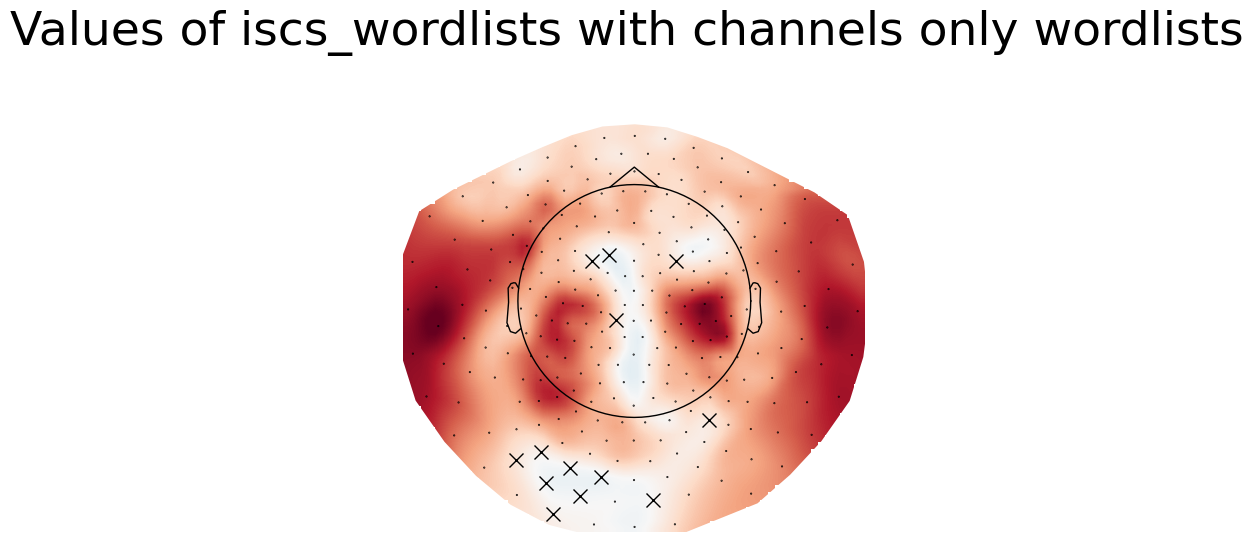

In [11]:
##plot for only zinnen
mask = mask_woorden_only

# Crear figura y eje con tamaño definido
fig, ax = plt.subplots(figsize=(6, 6))

# Dibujar el topomap sobre ese eje
im, _ = mne.viz.plot_topomap(
    data=iscs_bootstrap_zinnen,        
    pos=info,
    mask=mask,
    axes=ax,  # eje explícito
    cmap='RdBu_r',
    vlim=(-np.max(np.abs(values)), np.max(np.abs(values))),
    mask_params=dict(marker='x', markerfacecolor='green', markersize=10),
    contours=0,
    show=False  # mostrar después
)

# Título
fig.suptitle("Values of iscs_wordlists with channels only wordlists", fontsize=34)

# Mostrar figura
plt.show()

# Eliminar máscara para evitar conflictos posteriores
del mask

## Posibles comparaciones estadísticas
len(significant_channels_only_woorden): 25, len(significant_channels_only_zinnen): 92, len(significant_channels_intersection) 88

Primer problema, el numero de canales zinnen es claramente superior al de woorden, big problem, aunque la interseccion es alta, tal como esperaríamos. Seguramente esto sea porque hay ruido 

- comparación ACW-50 en zinnen entre estos canales zinnen y canales woorden  + comapracion en woorden de lo mismo

- comparación entre solo zinnen con intersection  en woorden y en zinnen (aunque ojo, esto es básicamente aceptar que los canales solo Zinnen son ruido)

- comapración en el promedio general de acw en ambas condiciones de los canalaes zinnen vs promedio general de canales woorden

- comparación de la intersección vs canales no signficativos: no sé muy bien como interpretar esto

- 

## general comparisons of ISC

In [12]:
##selección de valores
##matrices de valores de slope, divididas por condicion y tipo de channel

## in this case we are going to use the values of all the channels,  as these are the valuues of ISC, wich are created comapring subjects 
X_zinnen = iscs_bootstrap_zinnen

X_woorden = iscs_bootstrap_woorden

print(f"X_zinnen.shape is {X_zinnen.shape}, X_woorden.shape is {X_woorden.shape}")  

X_zinnen.shape is (270,), X_woorden.shape is (270,)


In [13]:


##dependent condition
def paired_statistic(diff, _):
    return np.mean(diff)

# Crear el diccionario con nombres descriptivos
data_dict = {
    "X_zinnen": X_zinnen,
    "X_woorden": X_woorden}



print("Differences in ISC between conditions")
x= data_dict[f"X_zinnen"]
##notice that in this comparison y is  ch_woorden_mean or ch_intersection_mean
y= data_dict[f"X_woorden"]


diff=x-y
# Permutation test
res = permutation_test(
    (diff, np.zeros_like(diff)),
    #
    statistic=paired_statistic,
    vectorized=False,
    n_resamples=10000,
    alternative='Greater', 
    random_state=42
)

print(f"Statistic value: {res.statistic:.6f}")
print(f"p-value: {res.pvalue:.6f}")

Differences in ISC between conditions
Statistic value: 0.002807
p-value: 0.000100
